In [1]:
# Робота з табличними даними та математичними операціями
import numpy as np
import pandas as pd

# Візуалізація даних і результатів
import matplotlib.pyplot as plt
import seaborn as sns

# Підготовка даних та оцінювання моделі
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Створення і навчання нейронної мережі
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Допоміжні бібліотеки
import random

In [2]:
# Робимо результати експерименту відтворюваними
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Налаштовуємо зовнішній вигляд графіків
sns.set_theme(style="whitegrid")

print(f"PyTorch version: {torch.__version__}")
print("Libraries imported successfully.")

PyTorch version: 2.10.0+cpu
Libraries imported successfully.


In [11]:
from pathlib import Path

# Коренева папка, у якій Kaggle зберігає додані набори даних
KAGGLE_INPUT_DIR = Path("/kaggle/input")
csv_files = list(KAGGLE_INPUT_DIR.rglob("*.csv"))
print("Found CSV files:")
for file_path in csv_files:
    print(file_path)

Found CSV files:
/kaggle/input/datasets/mchilamwar/predict-concrete-strength/ConcreteStrengthData.csv


In [13]:
if len(csv_files) != 1:
    raise ValueError(
        f"Expected exactly one CSV file, but found {len(csv_files)}. "
        "Please select the concrete dataset file explicitly."
    )
DATA_PATH = csv_files[0]

df = pd.read_csv(DATA_PATH)

print(f"Dataset path: {DATA_PATH}")
print(f"Dataset shape: {df.shape}")

Dataset path: /kaggle/input/datasets/mchilamwar/predict-concrete-strength/ConcreteStrengthData.csv
Dataset shape: (1030, 9)


In [14]:
print("Column names:")

for index, column in enumerate(df.columns):
    print(f"{index}: {column}")

Column names:
0: CementComponent 
1: BlastFurnaceSlag
2: FlyAshComponent
3: WaterComponent
4: SuperplasticizerComponent
5: CoarseAggregateComponent
6: FineAggregateComponent
7: AgeInDays
8: Strength


In [15]:
target_column = df.columns[-1]

print(f"Target column: {target_column}")

Target column: Strength


In [16]:
# X містить усі вхідні ознаки, крім цільової колонки
X = df.drop(columns=[target_column]).copy()

# y містить значення міцності бетону, які модель повинна передбачити
y = df[target_column].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

display(X.head())
display(y.head())

X shape: (1030, 8)
y shape: (1030,)


,CementComponent,BlastFurnaceSlag,FlyAshComponent,WaterComponent,SuperplasticizerComponent,CoarseAggregateComponent,FineAggregateComponent,AgeInDays
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


0    79.99
1    61.89
2    40.27
3    41.05
4    44.30
Name: Strength, dtype: float64

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"Training features shape: {X_train.shape}")
print(f"Test features shape:     {X_test.shape}")
print(f"Training target shape:   {y_train.shape}")
print(f"Test target shape:       {y_test.shape}")

Training features shape: (824, 8)
Test features shape:     (206, 8)
Training target shape:   (824,)
Test target shape:       (206,)


In [18]:
# Створюємо об'єкт для стандартизації ознак
scaler = StandardScaler()

# Вивчаємо параметри нормалізації тільки на навчальних даних
X_train_scaled = scaler.fit_transform(X_train)

# Застосовуємо ті самі параметри до тестових даних
X_test_scaled = scaler.transform(X_test)

print(f"Scaled training data shape: {X_train_scaled.shape}")
print(f"Scaled test data shape:     {X_test_scaled.shape}")

Scaled training data shape: (824, 8)
Scaled test data shape:     (206, 8)


In [19]:
print("Training feature means after scaling:")
print(np.round(X_train_scaled.mean(axis=0), 4))

print("\nTraining feature standard deviations after scaling:")
print(np.round(X_train_scaled.std(axis=0), 4))

Training feature means after scaling:
[ 0.  0.  0.  0. -0.  0. -0. -0.]

Training feature standard deviations after scaling:
[1. 1. 1. 1. 1. 1. 1. 1.]


In [20]:
class ConcreteStrengthModel(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.hidden_layer_1 = nn.Linear(input_size, 64)
        self.hidden_layer_2 = nn.Linear(64, 32)
        self.output_layer = nn.Linear(32, 1)

        self.activation = nn.ReLU()

    def forward(self, x):
        x = self.hidden_layer_1(x)
        x = self.activation(x)

        x = self.hidden_layer_2(x)
        x = self.activation(x)

        x = self.output_layer(x)

        return x

In [21]:
# Кількість колонок у нормалізованій матриці ознак
input_size = X_train_scaled.shape[1]

# Створюємо екземпляр нейронної мережі
model = ConcreteStrengthModel(input_size=input_size)

print(f"Number of input features: {input_size}")
print(model)

Number of input features: 8
ConcreteStrengthModel(
  (hidden_layer_1): Linear(in_features=8, out_features=64, bias=True)
  (hidden_layer_2): Linear(in_features=64, out_features=32, bias=True)
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
  (activation): ReLU()
)


In [22]:
total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Number of trainable parameters: {total_parameters}")

Number of trainable parameters: 2689


In [23]:
LEARNING_RATE = 0.01
BATCH_SIZE = 32
NUM_EPOCHS = 300

In [24]:
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.to_numpy(),
    dtype=torch.float32
).reshape(-1, 1)

y_test_tensor = torch.tensor(
    y_test.to_numpy(),
    dtype=torch.float32
).reshape(-1, 1)

In [25]:
print(
    f"X_train tensor: shape={X_train_tensor.shape}, "
    f"dtype={X_train_tensor.dtype}"
)

print(
    f"y_train tensor: shape={y_train_tensor.shape}, "
    f"dtype={y_train_tensor.dtype}"
)

print(
    f"X_test tensor:  shape={X_test_tensor.shape}, "
    f"dtype={X_test_tensor.dtype}"
)

print(
    f"y_test tensor:  shape={y_test_tensor.shape}, "
    f"dtype={y_test_tensor.dtype}"
)

X_train tensor: shape=torch.Size([824, 8]), dtype=torch.float32
y_train tensor: shape=torch.Size([824, 1]), dtype=torch.float32
X_test tensor:  shape=torch.Size([206, 8]), dtype=torch.float32
y_test tensor:  shape=torch.Size([206, 1]), dtype=torch.float32


In [26]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

In [27]:
TensorDataset(X_train_tensor, y_train_tensor)

In [28]:
features, target = train_dataset[0]

print(f"Feature shape: {features.shape}")
print(f"Target shape:  {target.shape}")

Feature shape: torch.Size([8])
Target shape:  torch.Size([1])


In [35]:
train_generator = torch.Generator().manual_seed(RANDOM_STATE)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_generator
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [36]:
batch_features, batch_targets = next(iter(train_loader))

print(f"Feature batch shape: {batch_features.shape}")
print(f"Target batch shape:  {batch_targets.shape}")

Feature batch shape: torch.Size([32, 8])
Target batch shape:  torch.Size([32, 1])


In [37]:
criterion = nn.MSELoss()

In [38]:
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE
)

In [39]:
print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of epochs: {NUM_EPOCHS}")

Loss function: MSELoss()
Optimizer: SGD
Learning rate: 0.01
Batch size: 32
Number of epochs: 300


In [40]:
train_loss_history = []

for epoch in range(NUM_EPOCHS):
    model.train()

    running_loss = 0.0

    for batch_features, batch_targets in train_loader:
        optimizer.zero_grad()

        predictions = model(batch_features)

        loss = criterion(predictions, batch_targets)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * batch_features.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_loss_history.append(epoch_loss)

    if (epoch + 1) % 25 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch + 1:3d}/{NUM_EPOCHS}], "
            f"Training MSE: {epoch_loss:.4f}"
        )

Epoch [  1/300], Training MSE: 1068.2175
Epoch [ 25/300], Training MSE: 45.3605
Epoch [ 50/300], Training MSE: 22.7322
Epoch [ 75/300], Training MSE: 21.6623
Epoch [100/300], Training MSE: 16.7440
Epoch [125/300], Training MSE: 16.4778
Epoch [150/300], Training MSE: 16.5937
Epoch [175/300], Training MSE: 15.3215
Epoch [200/300], Training MSE: 14.8461
Epoch [225/300], Training MSE: 11.6312
Epoch [250/300], Training MSE: 12.6012
Epoch [275/300], Training MSE: 9.4832
Epoch [300/300], Training MSE: 9.7035


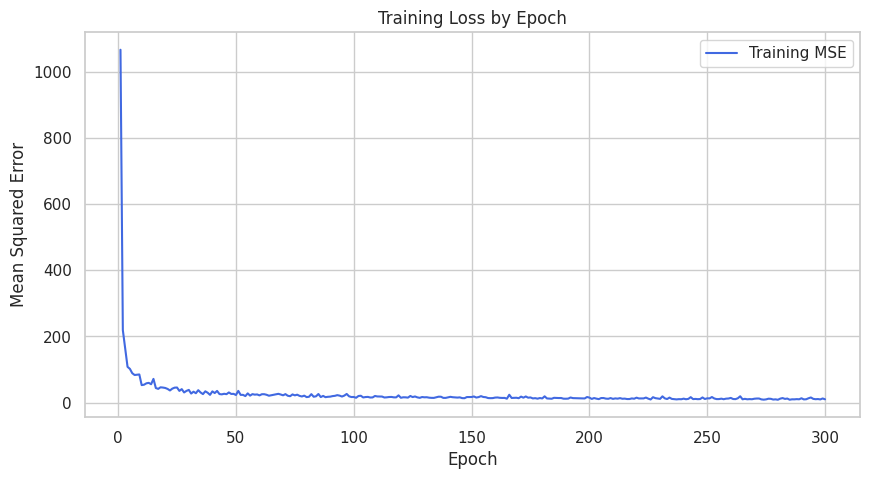

In [41]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_loss_history,
    color="royalblue",
    label="Training MSE"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Training Loss by Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [42]:
model.eval()

with torch.no_grad():
    test_predictions_tensor = model(X_test_tensor)

y_test_values = y_test_tensor.cpu().numpy().reshape(-1)
test_predictions = test_predictions_tensor.cpu().numpy().reshape(-1)

print(f"Number of actual values: {len(y_test_values)}")
print(f"Number of predictions:   {len(test_predictions)}")

Number of actual values: 206
Number of predictions:   206


In [43]:
test_mse = mean_squared_error(
    y_test_values,
    test_predictions
)

test_rmse = np.sqrt(test_mse)

test_mae = mean_absolute_error(
    y_test_values,
    test_predictions
)

test_r2 = r2_score(
    y_test_values,
    test_predictions
)

print("Test metrics:")
print(f"MSE:  {test_mse:.4f} MPa²")
print(f"RMSE: {test_rmse:.4f} MPa")
print(f"MAE:  {test_mae:.4f} MPa")
print(f"R²:   {test_r2:.4f}")

Test metrics:
MSE:  24.6341 MPa²
RMSE: 4.9633 MPa
MAE:  3.2874 MPa
R²:   0.9044


In [44]:
predictions_df = pd.DataFrame({
    "Actual strength": y_test_values,
    "Predicted strength": test_predictions
})

predictions_df["Absolute error"] = np.abs(
    predictions_df["Actual strength"]
    - predictions_df["Predicted strength"]
)

predictions_df.head(10)

,Actual strength,Predicted strength,Absolute error
0,52.910000,51.661884,1.248116
1,55.900002,40.862370,15.037632
2,74.500000,80.831421,6.331421
3,35.299999,34.497993,0.802006
4,10.540000,9.042402,1.497598
5,44.279999,45.142658,0.862659
6,23.690001,27.534206,3.844206
7,45.369999,53.748428,8.378429
8,37.400002,33.971077,3.428925
9,48.849998,50.703323,1.853325


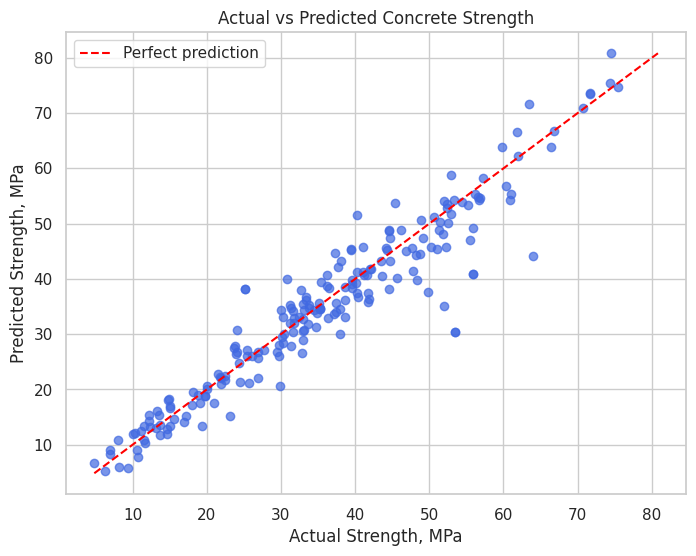

In [45]:
minimum_value = min(
    y_test_values.min(),
    test_predictions.min()
)

maximum_value = max(
    y_test_values.max(),
    test_predictions.max()
)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_values,
    test_predictions,
    alpha=0.7,
    color="royalblue"
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    color="red",
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual Strength, MPa")
plt.ylabel("Predicted Strength, MPa")
plt.title("Actual vs Predicted Concrete Strength")
plt.legend()
plt.grid(True)
plt.show()

In [46]:
# Номери епох від 1 до NUM_EPOCHS
epochs = np.arange(1, len(train_loss_history) + 1)

# Межі для графіка фактичних і прогнозованих значень
plot_min = min(
    y_test_values.min(),
    test_predictions.min()
)

plot_max = max(
    y_test_values.max(),
    test_predictions.max()
)

# Сортуємо тестові приклади за фактичною міцністю
sort_indices = np.argsort(y_test_values)

actual_sorted = y_test_values[sort_indices]
predicted_sorted = test_predictions[sort_indices]

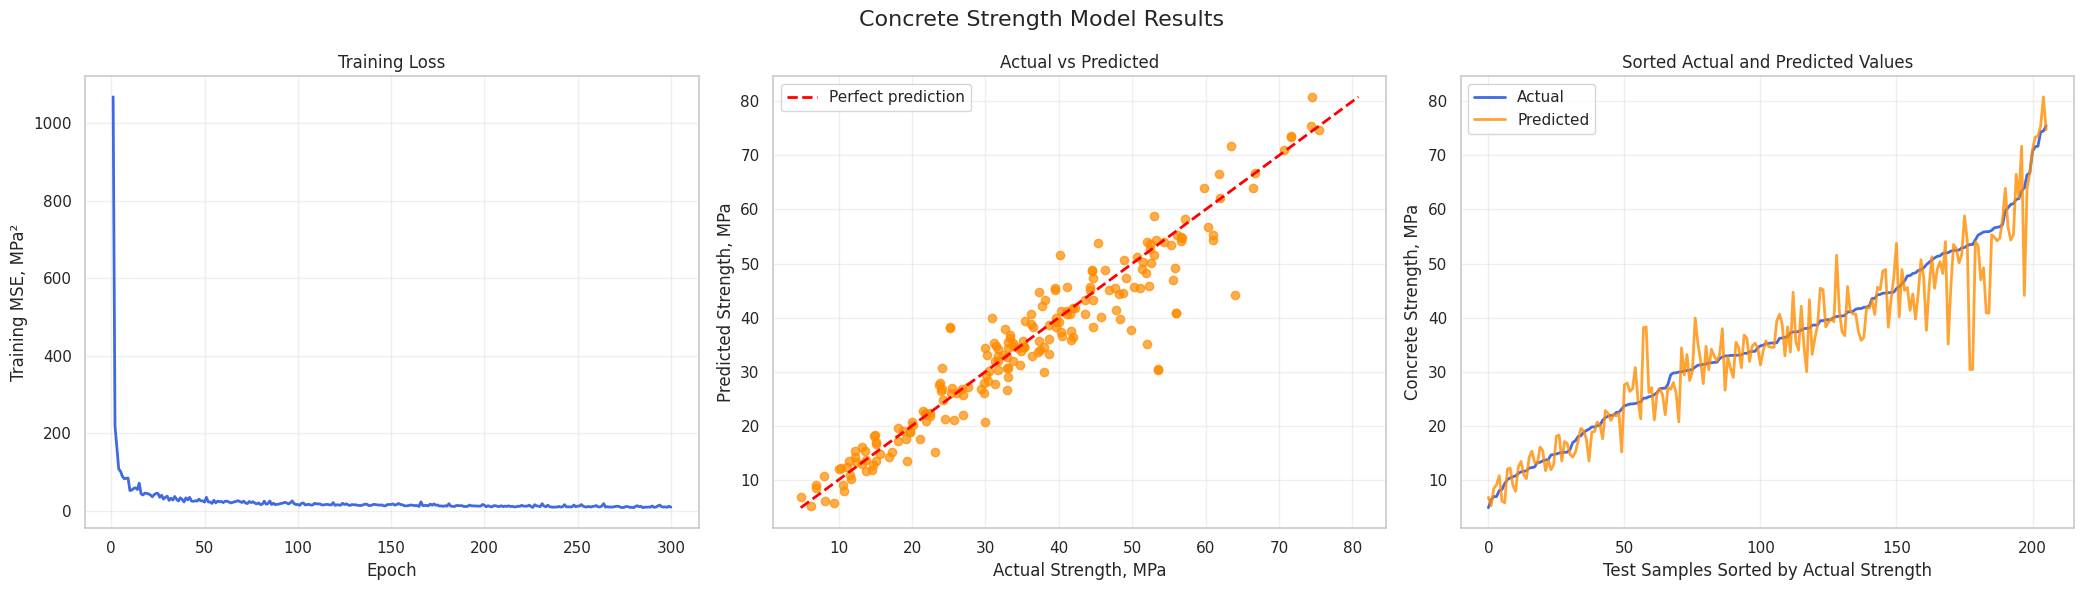

In [47]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(21, 6)
)

# 1. Графік функції втрат
axes[0].plot(
    epochs,
    train_loss_history,
    color="royalblue",
    linewidth=2
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training MSE, MPa²")
axes[0].set_title("Training Loss")
axes[0].grid(True, alpha=0.3)

# 2. Фактичні значення проти прогнозованих
axes[1].scatter(
    y_test_values,
    test_predictions,
    color="darkorange",
    alpha=0.7
)

axes[1].plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect prediction"
)

axes[1].set_xlabel("Actual Strength, MPa")
axes[1].set_ylabel("Predicted Strength, MPa")
axes[1].set_title("Actual vs Predicted")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Порівняння відсортованих значень
axes[2].plot(
    actual_sorted,
    color="royalblue",
    linewidth=2,
    label="Actual"
)

axes[2].plot(
    predicted_sorted,
    color="darkorange",
    linewidth=2,
    alpha=0.8,
    label="Predicted"
)

axes[2].set_xlabel("Test Samples Sorted by Actual Strength")
axes[2].set_ylabel("Concrete Strength, MPa")
axes[2].set_title("Sorted Actual and Predicted Values")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle(
    "Concrete Strength Model Results",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [48]:
initial_loss = train_loss_history[0]
final_loss = train_loss_history[-1]

best_loss = min(train_loss_history)
best_epoch = np.argmin(train_loss_history) + 1

loss_reduction = (
    (initial_loss - final_loss)
    / initial_loss
    * 100
)

print(f"Initial training MSE: {initial_loss:.4f} MPa²")
print(f"Final training MSE:   {final_loss:.4f} MPa²")
print(f"Best training MSE:    {best_loss:.4f} MPa²")
print(f"Best epoch:           {best_epoch}")
print(f"Loss reduction:       {loss_reduction:.2f}%")

Initial training MSE: 1068.2175 MPa²
Final training MSE:   9.7035 MPa²
Best training MSE:    8.3324 MPa²
Best epoch:           280
Loss reduction:       99.09%


In [49]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"Model training set: {X_fit.shape}")
print(f"Validation set:     {X_val.shape}")
print(f"Final test set:     {X_test.shape}")

Model training set: (659, 8)
Validation set:     (165, 8)
Final test set:     (206, 8)
